/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


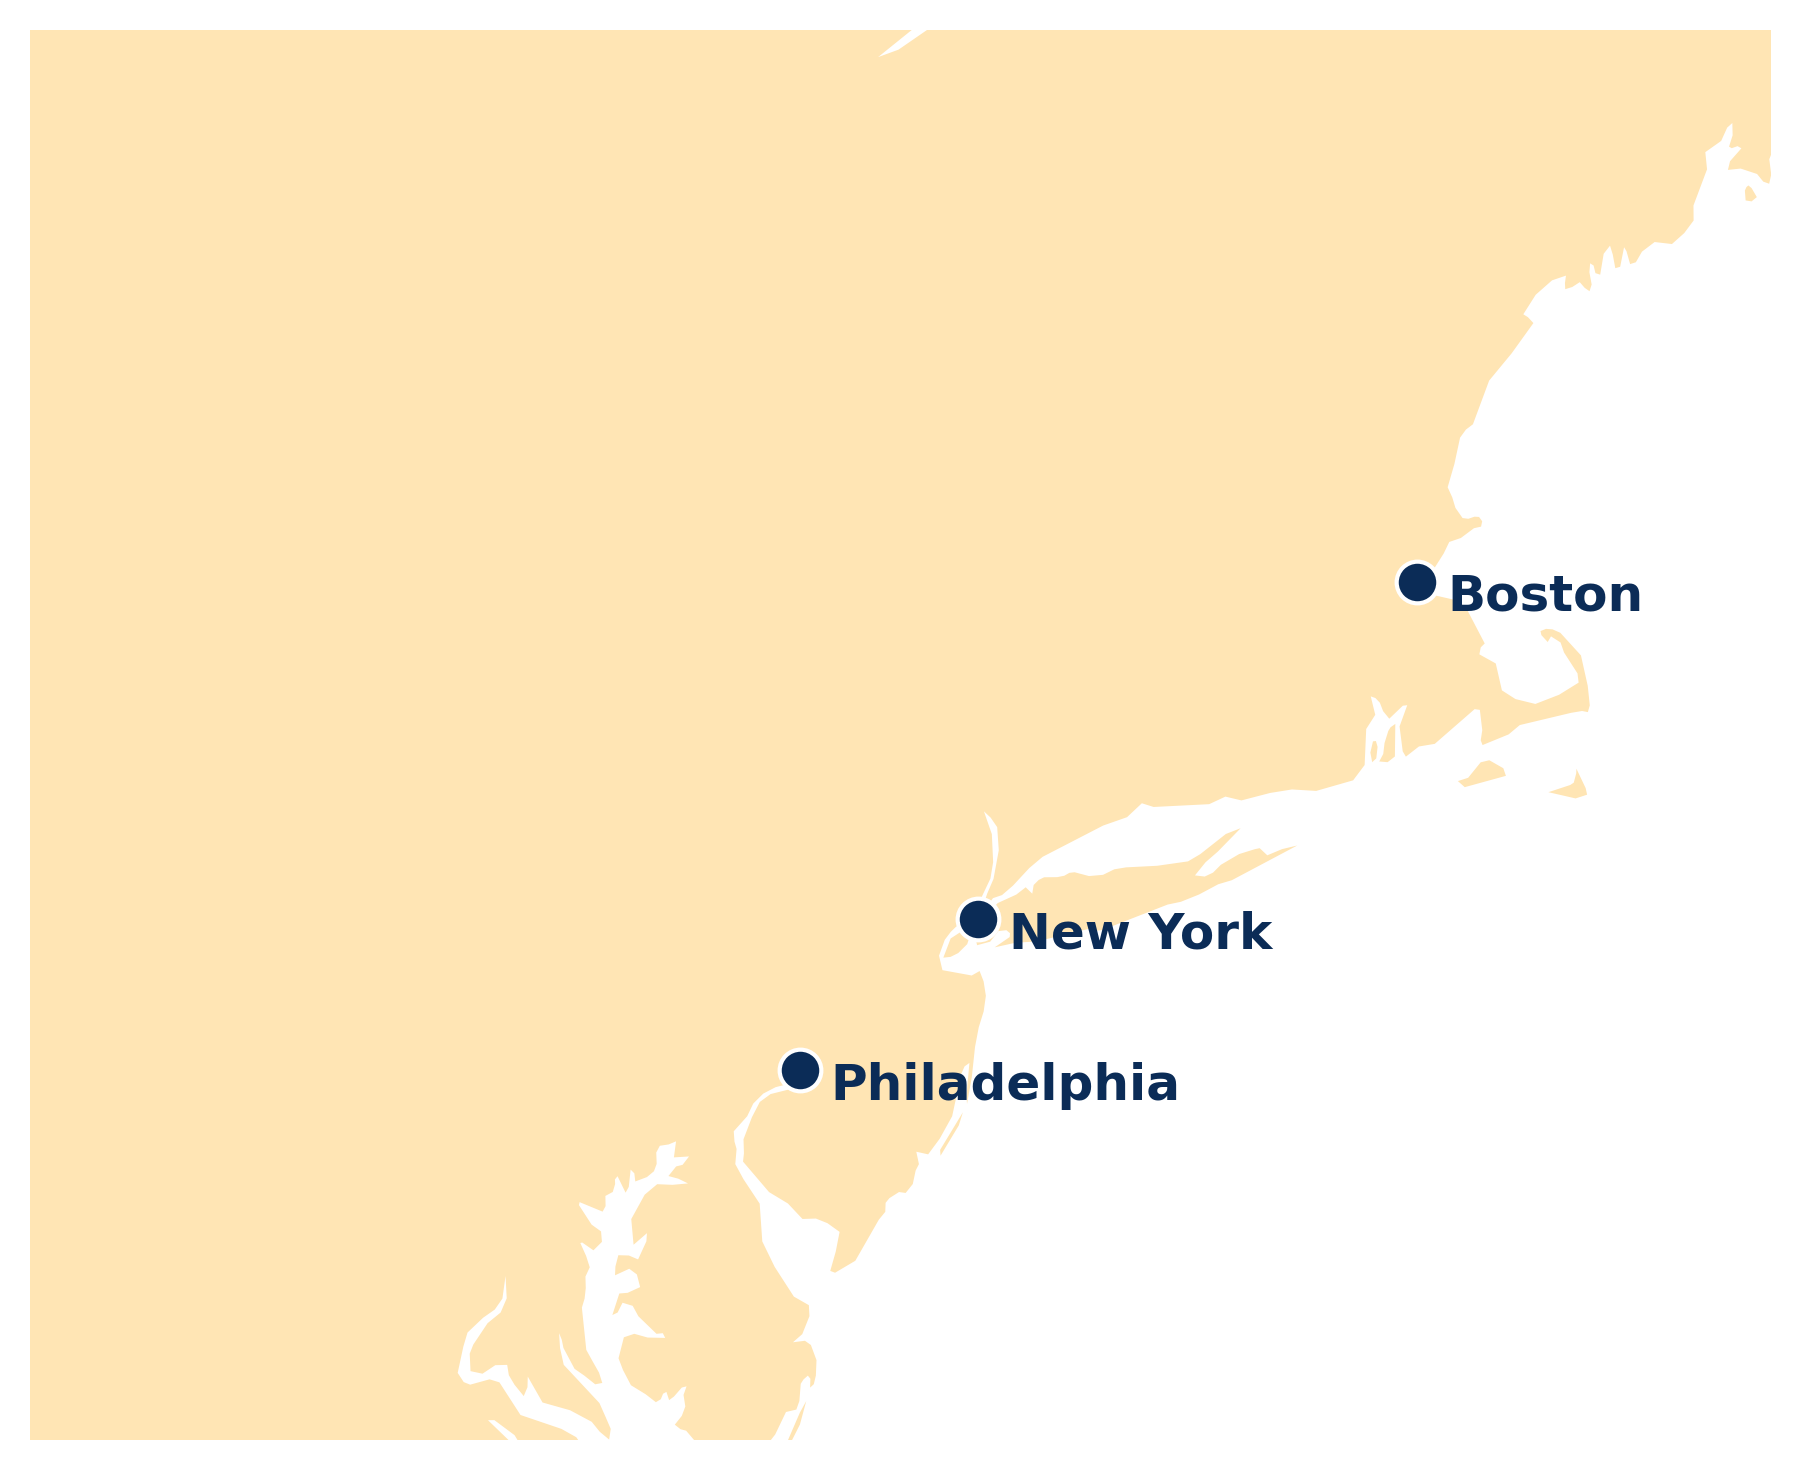

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Coordenadas (latitud, longitud)
cities = {
    "New York":     (40.7128, -74.0060),
    "Philadelphia": (39.9526, -75.1652),
    "Boston":       (42.3601, -71.0589),
}

# Proyección y figura
fig = plt.figure(figsize=(10, 5), dpi=300)
proj = ccrs.LambertConformal(central_longitude=-74, central_latitude=41)
ax = plt.axes(projection=proj)

# Zona “zoomed in” del noreste de EEUU
ax.set_extent([-80, -69, 38, 45], crs=ccrs.PlateCarree())

# ---- ESTILO DEL MAPA ----
# Tierra en color amarillo melocotón y SIN líneas de contorno
ax.add_feature(cfeature.LAND.with_scale('50m'),
               facecolor="#FFE5B4",  # amarillo melocotón suave
               edgecolor="none")

# NO añadimos coastlines, borders ni states para evitar líneas negras

# Dibujar las ciudades
for name, (lat, lon) in cities.items():
    ax.plot(
        lon, lat,
        marker="o",
        markersize=10,
        markeredgecolor="white",
        markerfacecolor="#0b2c57",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    ax.text(
        lon + 0.2, lat - 0.15, name,
        transform=ccrs.PlateCarree(),
        fontsize=12,
        color="#0b2c57",
        weight="bold",
        zorder=6,
    )

# Quitar ejes / bordes de gráfico
ax.axis("off")

plt.tight_layout()

# Guardar con fondo transparente
plt.savefig(
    "mapa_dsmarket_melocoton_transparente.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()
